In this seminar we introduce the basic notions of graph theory required for studying graph isomorphism, connectedness, graph complements, and elementary Ramsey theory.

# Graphs

A **simple graph** is a pair

$$
G=(V,E),
$$

where

- $V$ is a finite set of vertices;
- $E\subseteq \binom{V}{2}$ is a set of unordered pairs of distinct vertices called **edges**.

Throughout the seminar we consider only finite simple graphs.

If $|V|=p$, $|E|=q$, then $G$ is called a **$(p,q)$-graph**.

The complete graph on $n$ vertices is denoted by $K_n$.

## Degree of a Vertex

The **degree** of a vertex $v$ is the number of edges incident with $v$. It is denoted by $d(v)$.

The list

$$
(d(v_1),\ldots,d(v_n))
$$

is called the **degree sequence** of the graph. Usually the degree sequence is written in non-increasing order.

## Theorem (Handshake Lemma)

For every graph $G$,

$$
\sum_{v\in V(G)} d(v)=2|E(G)|.
$$

A sequence $(d_1,\ldots,d_n)$ is called **graphical** if there exists a graph whose degree sequence is equal to this sequence.

The Handshake Lemma immediately implies a necessary condition:

$$
d_1+\cdots+d_n
$$

must be an even number. This condition is necessary but not sufficient. For example, $(4,4,4,4,2)$ is not graphical.

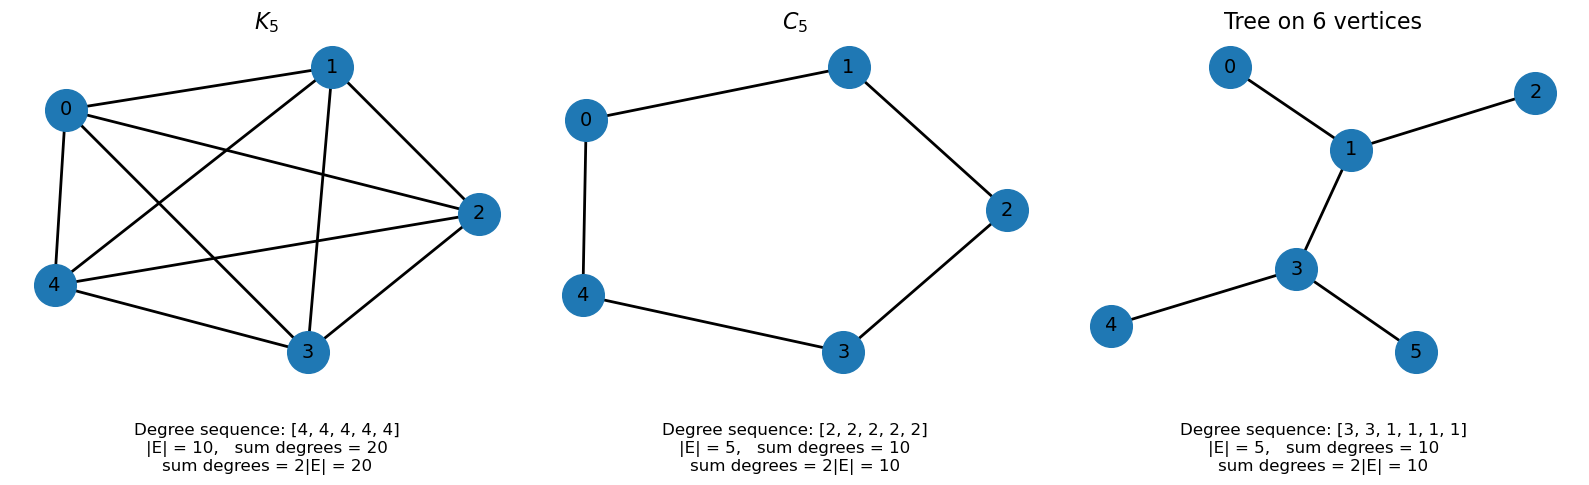

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

graphs = {
    r"$K_5$": nx.complete_graph(5),
    r"$C_5$": nx.cycle_graph(5),
    "Tree on 6 vertices": nx.Graph([(0,1), (1,2), (1,3), (3,4), (3,5)])
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (title, G) in zip(axes, graphs.items()):
    pos = nx.spring_layout(G, seed=7)

    nx.draw(
        G,
        pos,
        ax=ax,
        with_labels=True,
        node_size=900,
        font_size=14,
        width=2
    )

    deg_seq = sorted([d for _, d in G.degree()], reverse=True)
    num_edges = G.number_of_edges()
    sum_degrees = sum(dict(G.degree()).values())

    ax.set_title(title, fontsize=16)

    ax.text(
        0.5,
        -0.12,
        f"Degree sequence: {deg_seq}\n"
        f"|E| = {num_edges},   sum degrees = {sum_degrees}\n"
        f"sum degrees = 2|E| = {2*num_edges}",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=12
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

# Graph Isomorphism

Graphs $G=(V,E)$ and $H=(W,F)$ are called **isomorphic** if there exists a bijection $\varphi:V\to W$ such that

$$
uv\in E
\quad\Longleftrightarrow\quad
\varphi(u)\varphi(v)\in F.
$$

The map $\varphi$ is called an **isomorphism**.

We write $G\cong H$.

Intuitively, two graphs are isomorphic if one can be obtained from the other merely by relabelling the vertices.

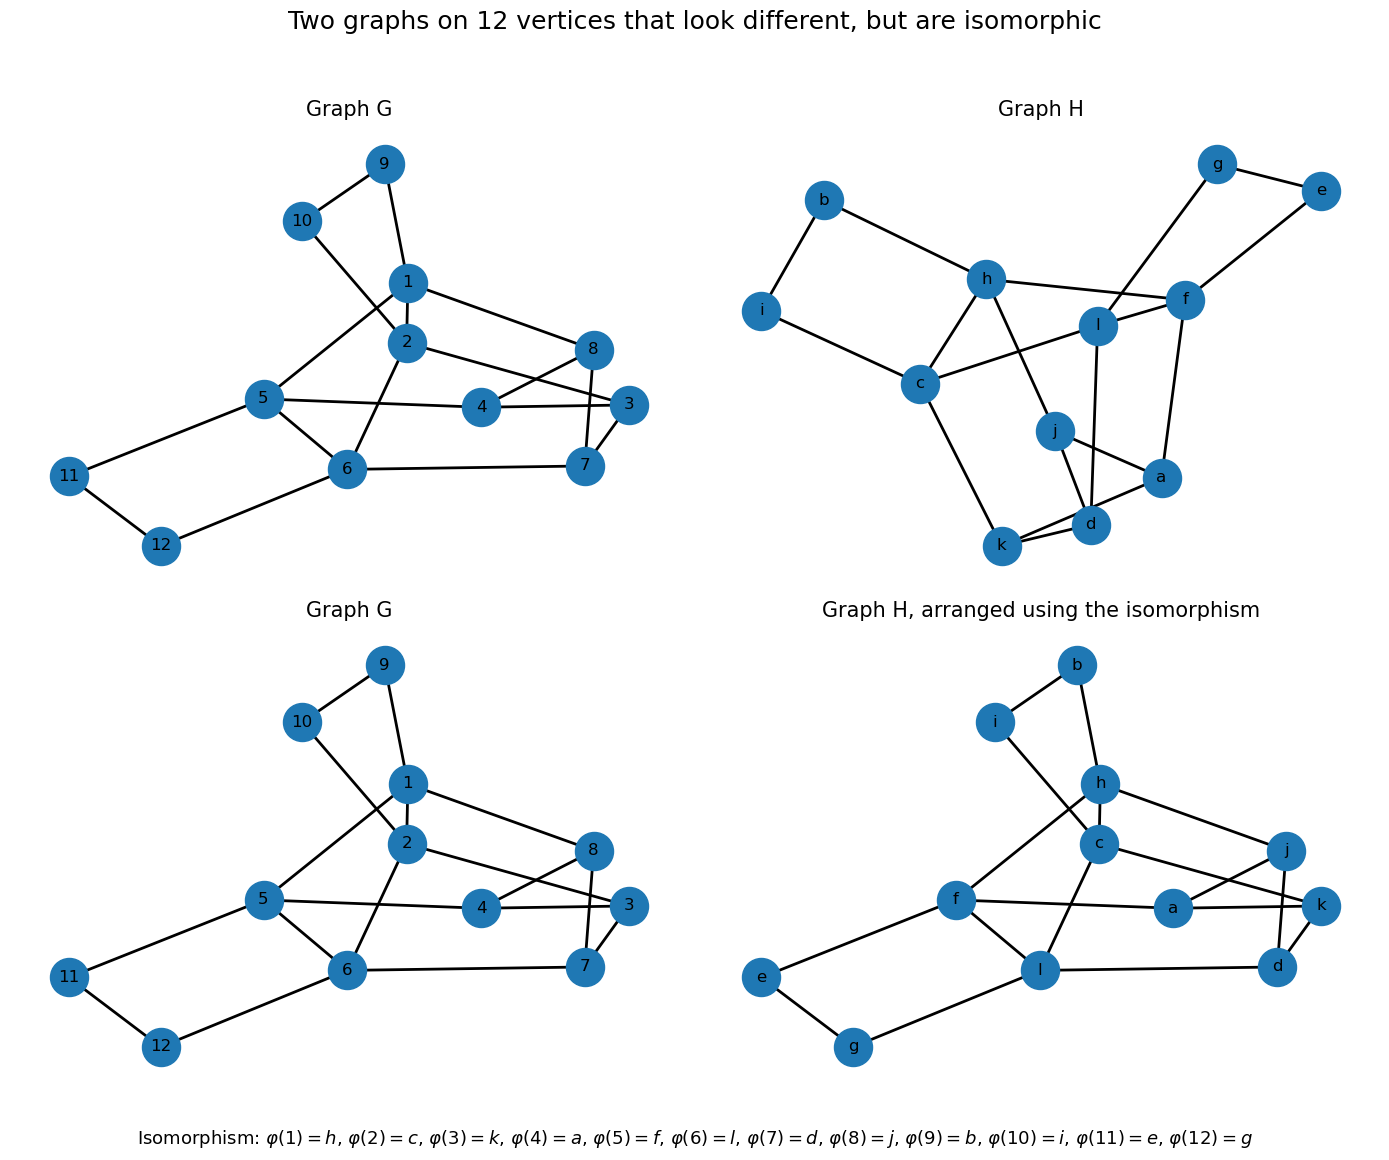

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

# -----------------------------
# Graph G on 12 vertices
# -----------------------------
G_edges = [
    # Main 8-cycle
    (1, 2), (2, 3), (3, 4), (4, 5),
    (5, 6), (6, 7), (7, 8), (8, 1),

    # Chords
    (1, 5), (2, 6), (3, 7), (4, 8),

    # Attachments
    (1, 9), (9, 10),
    (5, 11), (11, 12),

    # Extra asymmetry
    (2, 10), (6, 12)
]

G = nx.Graph(G_edges)

# Isomorphism phi: V(G) -> V(H)
phi = {
    1: "h",
    2: "c",
    3: "k",
    4: "a",
    5: "f",
    6: "l",
    7: "d",
    8: "j",
    9: "b",
    10: "i",
    11: "e",
    12: "g"
}

# Graph H is obtained by relabeling G using phi
H = nx.relabel_nodes(G, phi)

# -----------------------------
# Layouts
# -----------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# First row: misleading layouts
pos_G_bad = nx.spring_layout(G, seed=3)
pos_H_bad = nx.spring_layout(H, seed=25)

# Second row: layouts revealing the isomorphism
pos_G_good = nx.spring_layout(G, seed=3)
pos_H_good = {phi[v]: pos_G_good[v] for v in G.nodes()}

plots = [
    (axes[0, 0], G, pos_G_bad, "Graph G"),
    (axes[0, 1], H, pos_H_bad, "Graph H"),
    (axes[1, 0], G, pos_G_good, "Graph G"),
    (axes[1, 1], H, pos_H_good, "Graph H, arranged using the isomorphism")
]

for ax, graph, pos, title in plots:
    nx.draw(
        graph,
        pos,
        ax=ax,
        with_labels=True,
        node_size=750,
        font_size=12,
        width=2
    )
    ax.set_title(title, fontsize=15)
    ax.axis("off")

fig.suptitle(
    "Two graphs on 12 vertices that look different, but are isomorphic",
    fontsize=18
)

# Bijection text
bijection_text = ", ".join([fr"$\varphi({v})={phi[v]}$" for v in sorted(phi)])

fig.text(
    0.5,
    0.035,
    "Isomorphism: " + bijection_text,
    ha="center",
    fontsize=13
)

plt.tight_layout(rect=[0, 0.07, 1, 0.95])
plt.show()

## Invariants of Isomorphism

A quantity that is preserved under isomorphism is called a **graph invariant**.

If

$$
G\cong H,
$$

then the following quantities coincide:

- number of vertices;
- number of edges;
- degree sequence;
- number of connected components;
- number of cycles of each length.

Graph invariants are useful for proving that two graphs are not isomorphic.

# Connected Graphs

A **path** in a graph is a sequence of vertices

$$
v_0,v_1,\ldots,v_k
$$

such that every consecutive pair of vertices is connected by an edge.


<p align="center">
<img src="images/path_2.png" width="500">
</p>

A graph is called **connected** if every pair of vertices can be joined by a path.

A maximal connected subgraph is called a **connected component**.

Every graph can be uniquely decomposed into connected components.

<p align="center">
<img src="images/connected_1.png" width="500">
</p>

## Trees

A graph is called a **tree** if it is connected and contains no cycles.

### Theorem (Equivalent Characterizations of Trees)

Let $G=(V,E)$ be a graph with $n$ vertices. The following statements are equivalent:

1. $G$ is a tree.

2. $G$ is connected and has exactly \(n-1\) edges.

3. $G$ is acyclic and has exactly \(n-1\) edges.

4. $G$ is connected, and every edge is a bridge (removing any edge disconnects the graph).

5. $G$ is acyclic, and adding any missing edge creates exactly one cycle.

6. For every pair of distinct vertices \(u,v\), there exists a unique path connecting \(u\) and \(v\).

7. $G$ is connected and removing any edge destroys connectivity.

8. $G$ is acyclic and adding any edge destroys acyclicity.

---

These characterizations are often used interchangeably. Depending on the problem, it may be easier to verify one of them rather than the original definition.

For example:

- To prove a graph is a tree, it is often easiest to show that it is connected and has \(n-1\) edges.
- To show that a graph is **not** a tree, it is enough to find either a cycle or two vertices that are not connected.
- The unique-path characterization is particularly useful in algorithms and network design.

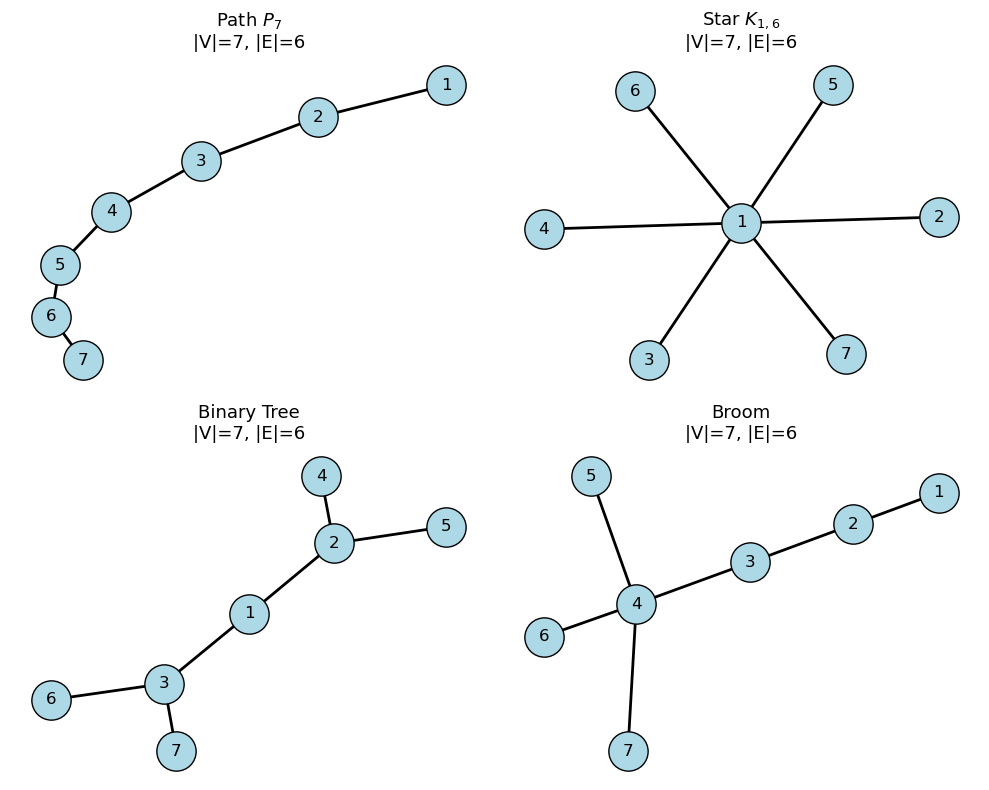

In [23]:
import networkx as nx
import matplotlib.pyplot as plt

# ----------------------------
# Four trees on 7 vertices
# ----------------------------

T1 = nx.path_graph(range(1, 8))  # Path P7

T2 = nx.star_graph(6)            # Star K1,6
T2 = nx.relabel_nodes(T2, lambda x: x + 1)

T3 = nx.Graph([                 # Binary tree
    (1,2), (1,3),
    (2,4), (2,5),
    (3,6), (3,7)
])

T4 = nx.Graph([                 # Broom
    (1,2), (2,3), (3,4),
    (4,5), (4,6), (4,7)
])

trees = [
    (T1, r"Path $P_7$"),
    (T2, r"Star $K_{1,6}$"),
    (T3, "Binary Tree"),
    (T4, "Broom")
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (T, title) in zip(axes.flatten(), trees):

    pos = nx.spring_layout(T, seed=42)

    nx.draw(
        T,
        pos,
        ax=ax,
        with_labels=True,
        node_size=800,
        node_color="lightblue",
        edgecolors="black",
        width=2,
        font_size=12
    )

    ax.set_title(
        f"{title}\n"
        f"|V|={T.number_of_nodes()}, "
        f"|E|={T.number_of_edges()}",
        fontsize=13
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

## Complement of a Graph

Let $G=(V,E)$ be a graph. The **complement** of $G$ is the graph $\overline G=(V,\overline E)$, where

$$
uv\in\overline E
\quad\Longleftrightarrow\quad
uv\notin E.
$$

Thus

$$
E(\overline G)
=
E(K_n)\setminus E(G).
$$

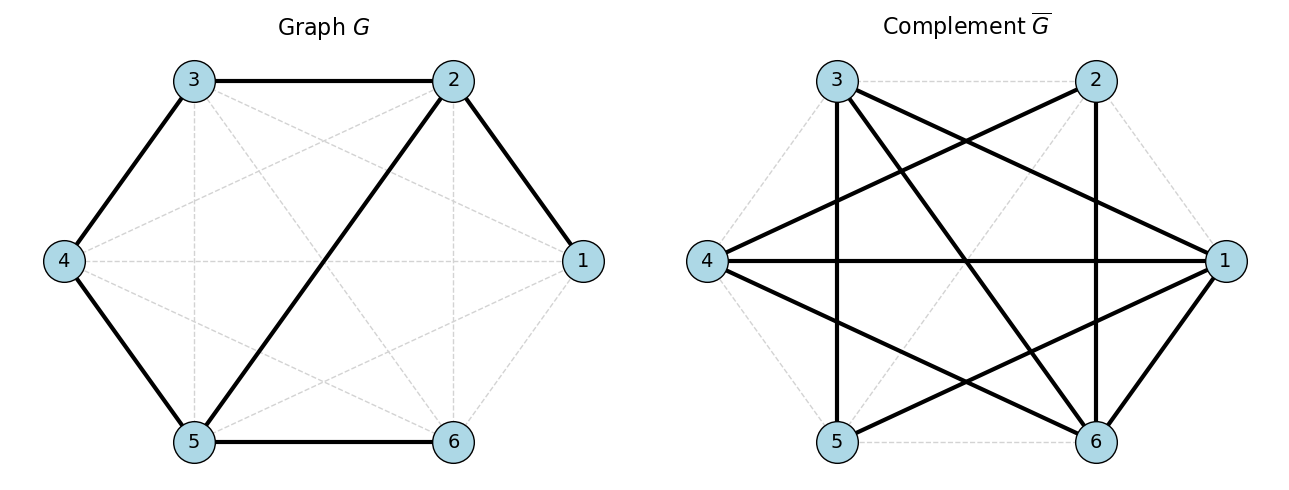

In [26]:
import networkx as nx
import matplotlib.pyplot as plt

# Vertices
V = list(range(1, 7))

# Original graph G
G = nx.Graph()
G.add_nodes_from(V)
G.add_edges_from([
    (1, 2), (2, 3), (3, 4), (4, 5),  # a path
    (2, 5), (5, 6)                   # extra edges
])

# Complement graph
Gc = nx.complement(G)

# Complete graph, only for faint background
K = nx.complete_graph(V)

# Same layout for both graphs
pos = nx.circular_layout(G)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, graph, title in [
    (axes[0], G, r"Graph $G$"),
    (axes[1], Gc, r"Complement $\overline{G}$")
]:
    # draw all possible edges faintly
    nx.draw_networkx_edges(
        K, pos, ax=ax,
        edge_color="lightgray",
        width=1,
        style="dashed"
    )

    # draw the actual edges
    nx.draw_networkx_edges(
        graph, pos, ax=ax,
        edge_color="black",
        width=3
    )

    nx.draw_networkx_nodes(
        graph, pos, ax=ax,
        node_size=900,
        node_color="lightblue",
        edgecolors="black"
    )

    nx.draw_networkx_labels(
        graph, pos, ax=ax,
        font_size=14
    )

    ax.set_title(title, fontsize=16)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Self-Complementary Graphs

A graph is called **self-complementary** if

$$
G\cong \overline G.
$$

### Proposition

If $G$ is self-complementary and has $n$ vertices, then

$$
|E(G)|
=
\frac12\binom{n}{2}.
$$

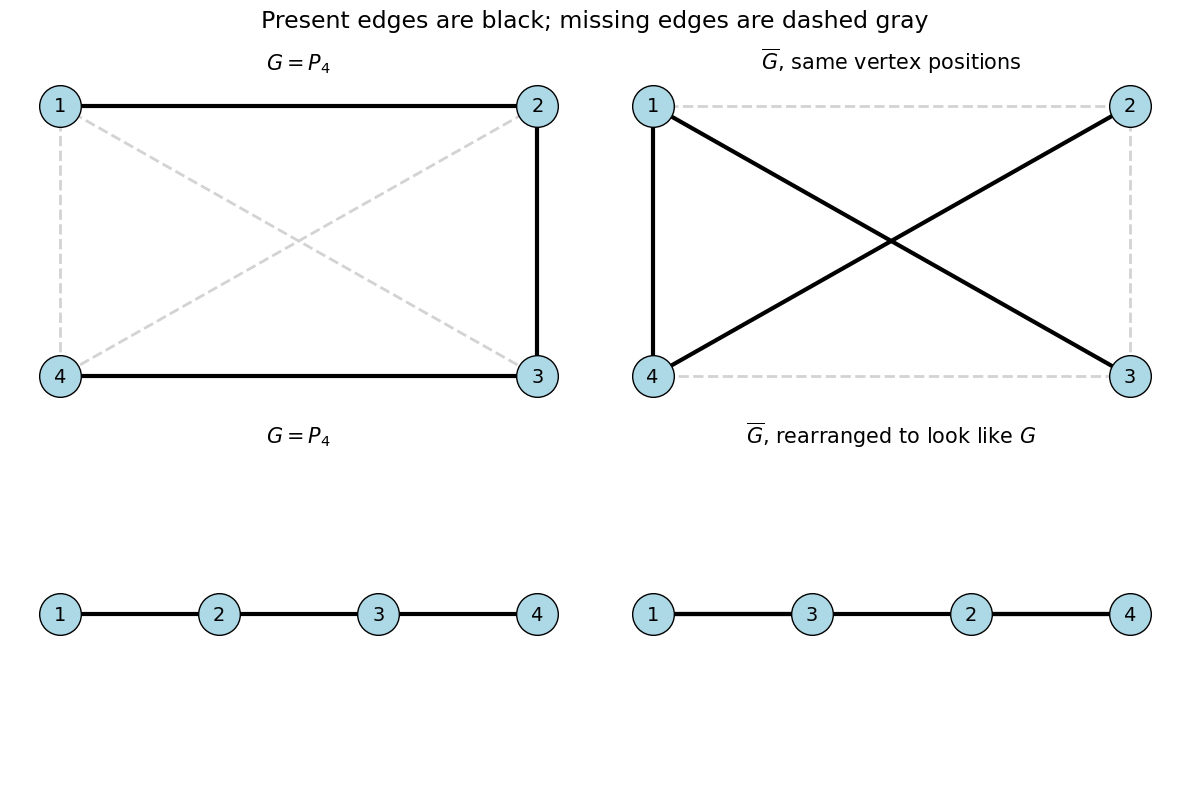

In [27]:
import networkx as nx
import matplotlib.pyplot as plt

# Self-complementary graph: P4
V = [1, 2, 3, 4]

G = nx.Graph()
G.add_nodes_from(V)
G.add_edges_from([(1, 2), (2, 3), (3, 4)])

Gc = nx.complement(G)

# Isomorphism phi: G -> complement(G)
phi = {
    1: 1,
    2: 3,
    3: 2,
    4: 4
}

# Same positions, to see the complement clearly
pos_same = {
    1: (0, 1),
    2: (1, 1),
    3: (1, 0),
    4: (0, 0)
}

# Rearranged positions, to see the isomorphism
pos_G = {
    1: (-1.5, 0),
    2: (-0.5, 0),
    3: (0.5, 0),
    4: (1.5, 0)
}

pos_Gc_iso = {phi[v]: pos_G[v] for v in G.nodes()}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plots = [
    (axes[0, 0], G,  pos_same, r"$G=P_4$"),
    (axes[0, 1], Gc, pos_same, r"$\overline{G}$, same vertex positions"),
    (axes[1, 0], G,  pos_G, r"$G=P_4$"),
    (axes[1, 1], Gc, pos_Gc_iso, r"$\overline{G}$, rearranged to look like $G$")
]

for ax, graph, pos, title in plots:
    missing_graph = nx.complement(graph)

    # Missing edges: dashed gray
    nx.draw_networkx_edges(
        missing_graph,
        pos,
        ax=ax,
        edge_color="lightgray",
        width=2,
        style="dashed"
    )

    # Present edges: black
    nx.draw_networkx_edges(
        graph,
        pos,
        ax=ax,
        edge_color="black",
        width=3
    )

    nx.draw_networkx_nodes(
        graph,
        pos,
        ax=ax,
        node_size=900,
        node_color="lightblue",
        edgecolors="black"
    )

    nx.draw_networkx_labels(
        graph,
        pos,
        ax=ax,
        font_size=14
    )

    ax.set_title(title, fontsize=15)
    ax.axis("off")

fig.suptitle(
    r"Present edges are black; missing edges are dashed gray",
    fontsize=17
)

plt.tight_layout()
plt.show()

### Connectivity of Complements

#### Theorem

For every graph $G$, at least one of the graphs $G$ and $\overline G$ is connected.

**Corollary**: Every self-complementary graph is connected.

# Ramsey Theory

Ramsey theory studies the appearance of order in sufficiently large structures.

## Definition

The **Ramsey number** $R(s,t)$ is the smallest integer $n$ such that every red-blue colouring of the edges of $K_n$ contains either

- a red copy of $K_s$, or
- a blue copy of $K_t$.

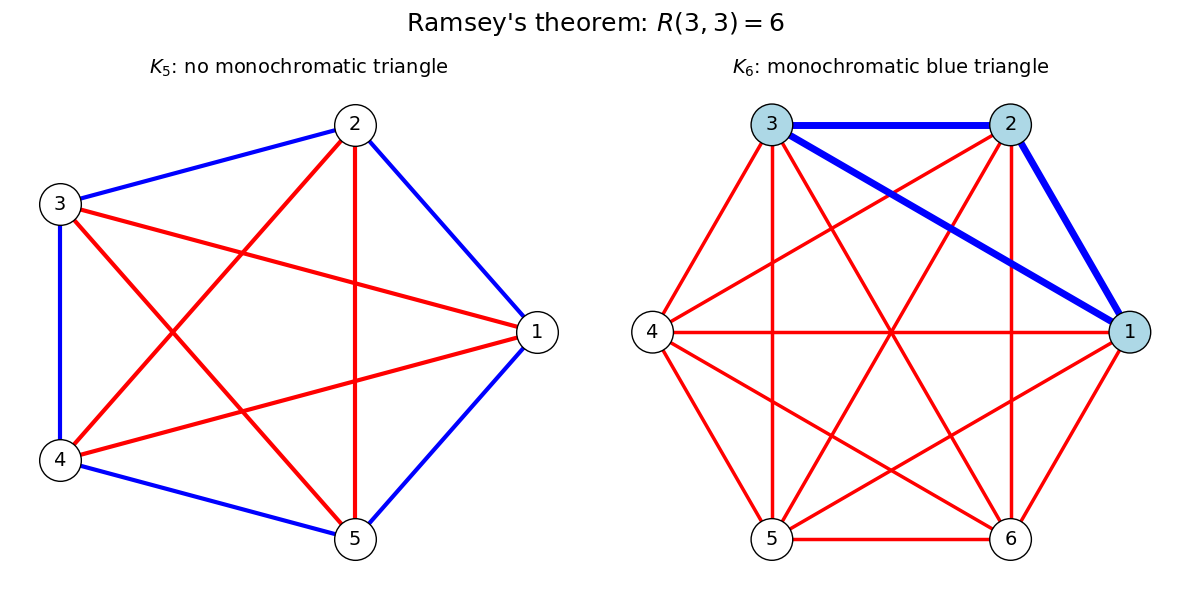

In [29]:
import networkx as nx
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# =====================================================
# LEFT: K5 without monochromatic triangles
# =====================================================

V5 = [1, 2, 3, 4, 5]

blue5 = nx.cycle_graph(V5)
red5 = nx.complement(blue5)

pos5 = nx.circular_layout(blue5)

nx.draw_networkx_edges(
    red5,
    pos5,
    ax=axes[0],
    edge_color="red",
    width=3
)

nx.draw_networkx_edges(
    blue5,
    pos5,
    ax=axes[0],
    edge_color="blue",
    width=3
)

nx.draw_networkx_nodes(
    blue5,
    pos5,
    ax=axes[0],
    node_size=900,
    node_color="white",
    edgecolors="black"
)

nx.draw_networkx_labels(
    blue5,
    pos5,
    ax=axes[0],
    font_size=14
)

axes[0].set_title(
    r"$K_5$: no monochromatic triangle",
    fontsize=14
)
axes[0].axis("off")

# =====================================================
# RIGHT: K6 with a monochromatic triangle
# =====================================================

V6 = [1, 2, 3, 4, 5, 6]

K6 = nx.complete_graph(V6)

# Blue triangle
blue_edges = [
    (1,2), (2,3), (1,3)
]

# All remaining edges red
red_edges = [
    e for e in K6.edges()
    if tuple(sorted(e)) not in {tuple(sorted(x)) for x in blue_edges}
]

pos6 = nx.circular_layout(K6)

# Red edges
nx.draw_networkx_edges(
    nx.Graph(red_edges),
    pos6,
    ax=axes[1],
    edge_color="red",
    width=2.5
)

# Blue triangle
nx.draw_networkx_edges(
    nx.Graph(blue_edges),
    pos6,
    ax=axes[1],
    edge_color="blue",
    width=5
)

# Highlight the monochromatic triangle
nx.draw_networkx_nodes(
    K6,
    pos6,
    ax=axes[1],
    node_size=900,
    node_color=[
        "lightblue" if v in [1,2,3] else "white"
        for v in V6
    ],
    edgecolors="black"
)

nx.draw_networkx_labels(
    K6,
    pos6,
    ax=axes[1],
    font_size=14
)

axes[1].set_title(
    r"$K_6$: monochromatic blue triangle",
    fontsize=14
)
axes[1].axis("off")

plt.suptitle(
    r"Ramsey's theorem: $R(3,3)=6$",
    fontsize=18
)

plt.tight_layout()
plt.show()

# How to Verify Whether Two Graphs Are Isomorphic

Determining whether two graphs are isomorphic is one of the fundamental problems of graph theory. 

The trivial step is to compare the number of vertices and edges.

## Step 1. Compare the Degree Sequences

Compute the degrees of all vertices and sort them in non-increasing order.

If the resulting sequences differ, the graphs are not isomorphic.

---

## Step 2. Compare Local Structures

Even if two graphs have the same degree sequence, they may still be non-isomorphic.

Useful quantities include:

- number of connected components;
- number of triangles;
- number of cycles of a given length;
- number of vertices of each degree;
- adjacency relations between high-degree vertices.

If any of these quantities differ, the graphs are not isomorphic.

---

## Step 3. Match Distinguished Vertices

Suppose the graphs have passed all previous tests.

Vertices with unique properties must correspond to each other under any isomorphism.

For example, if a graph contains exactly one vertex of degree $4$, then this vertex must be mapped to the unique degree-$4$ vertex of the other graph.

This often greatly reduces the number of possible bijections.

---

## Step 6. Construct an Explicit Bijection

After identifying corresponding vertices, attempt to define a bijection

$$
\varphi:V(G)\to V(H).
$$

One must verify that

$$
uv\in E(G)
\quad\Longleftrightarrow\quad
\varphi(u)\varphi(v)\in E(H)
$$

for every pair of vertices.

If such a bijection exists, then $G\cong H$.

# Beyond Graph Invariants: The Graph Isomorphism Problem

The method based on graph invariants is extremely useful in practice. However, there exist many pairs of non-isomorphic graphs that share all common invariants such as:

- number of vertices;
- number of edges;
- degree sequence;
- number of connected components;
- number of cycles of various lengths.

Consequently, a more systematic approach is required.

This leads to one of the most famous algorithmic problems in graph theory.

---

## The Graph Isomorphism Problem

### Input

Two graphs

$$
G=(V,E),
\qquad
H=(W,F)
$$

with $|V|=|W|=n$.

### Question

Does there exist a bijection $\varphi:V\to W$ such that

$$
uv\in E(G)
\quad\Longleftrightarrow\quad
\varphi(u)\varphi(v)\in E(H)?
$$

If such a bijection exists, the graphs are isomorphic.

---

## A Naive Algorithm

A brute-force approach consists of checking all possible bijections

$$
\varphi:V\to W.
$$

Since there are $n!$ such bijections, the running time is approximately $O(n!)$.

Using Stirling's approximation,

$$
n!
\approx
\sqrt{2\pi n}
\left(\frac{n}{e}\right)^n,
$$

which grows extremely rapidly.

### How Long Would Brute Force Take?

Suppose, very optimistically, that a modern computer can check $10^9$ (one billion) bijections per second. Then the running time is approximately $\frac{n!}{10^9}$ seconds.

For example, $20! \approx 2.4\cdot 10^{18}$.

Hence brute force would take approximately $\frac{20!}{10^9} \approx 2.4\cdot 10^9$ seconds.

Since one year has about $3.15\cdot 10^7$ seconds, this is approximately $\frac{2.4\cdot 10^9}{3.15\cdot 10^7}\approx 77$ years.

Thus, even for graphs with only $20$ vertices, the naive algorithm is already infeasible.

---

The situation becomes much worse as $n$ grows.

| Number of vertices $n$ | Number of bijections $n!$ | Time at $10^9$ checks/sec |
|---:|---:|---:|
| $10$ | $3.6\cdot 10^6$ | less than $1$ second |
| $15$ | $1.3\cdot 10^{12}$ | about $22$ minutes |
| $20$ | $2.4\cdot 10^{18}$ | about $77$ years |
| $25$ | $1.6\cdot 10^{25}$ | about $5\cdot 10^8$ years |
| $30$ | $2.7\cdot 10^{32}$ | about $8.4\cdot 10^{15}$ years |

Therefore, the brute-force method is not a serious algorithm for graph isomorphism, except for very small graphs.

This explains why more sophisticated methods are needed: instead of checking all possible vertex permutations, modern algorithms try to exploit graph structure, vertex refinement, symmetry, and group-theoretic ideas.

---

## Complexity-Theoretic Status

The Graph Isomorphism problem occupies a unique position in complexity theory.

It is known that

$$
\text{GI}\in\text{NP}.
$$

Indeed, if an isomorphism exists, it can be verified in polynomial time.

Surprisingly, despite decades of research:

- no polynomial-time algorithm is known for general graphs;
- no proof exists that the problem is NP-complete.

Therefore Graph Isomorphism is one of the few classical problems whose precise complexity remains unknown.

---

## The Weisfeiler--Leman Method

The most important practical idea is the **Weisfeiler--Leman refinement algorithm**.

The basic version proceeds as follows.

1. Assign every vertex the same color.
2. Repeatedly recolor each vertex according to the multiset of colors of its neighbors.
3. Continue until the coloring stabilizes.

If two graphs produce different color distributions, they cannot be isomorphic.

The algorithm runs in polynomial time.

In practice, it distinguishes most graphs encountered in applications.


---

## Babai's Breakthrough (2015)

Babai proved that Graph Isomorphism can be solved in

$$
2^{(\log n)^{O(1)}}
$$

time.

Such running times are called **quasi-polynomial**.


They are significantly smaller than exponential running times such as $2^n$ but still larger than every polynomial $n^k$.

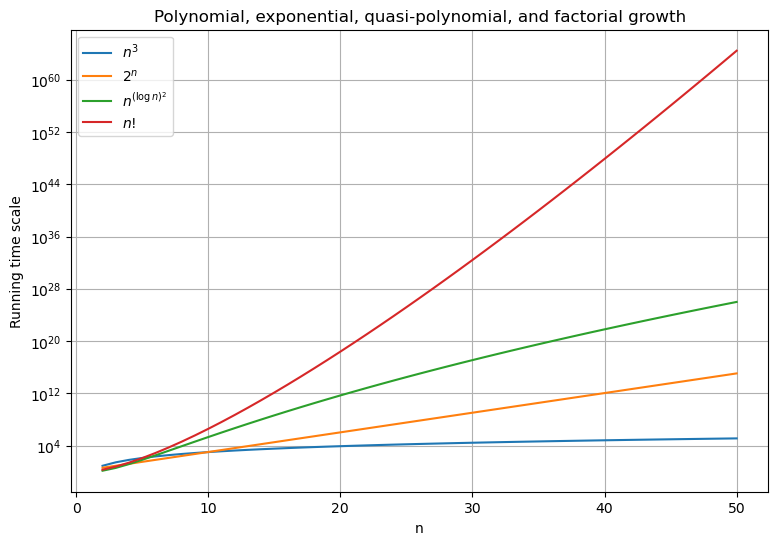

In [8]:
ns = np.arange(2, 51)

poly = ns**3
expo = 2**ns
quasi = np.array([n ** (math.log(n)**2) for n in ns])
fact = np.array([math.factorial(int(n)) for n in ns], dtype=float)

plt.figure(figsize=(9, 6))
plt.plot(ns, poly, label=r"$n^3$")
plt.plot(ns, expo, label=r"$2^n$")
plt.plot(ns, quasi, label=r"$n^{(\log n)^2}$")
plt.plot(ns, fact, label=r"$n!$")

plt.yscale("log")
plt.xlabel("n")
plt.ylabel("Running time scale")
plt.title("Polynomial, exponential, quasi-polynomial, and factorial growth")
plt.legend()
plt.grid(True)
plt.show()

## Special Classes of Graphs

Although the complexity of the Graph Isomorphism problem is unknown for arbitrary graphs, polynomial-time algorithms are known for many important graph families.

Examples include:

- trees;
- planar graphs;
- interval graphs;
- bounded-degree graphs;
- graphs of bounded treewidth.

For trees, graph isomorphism can be solved in

$$
O(n)
$$

time.

Consequently, the difficulty of the Graph Isomorphism problem comes not from sparse or highly structured graphs, but rather from graphs possessing many symmetries.

In practice, special graph classes arise frequently in computer science. Therefore, many real-world instances can be solved much faster than the worst-case theoretical bounds suggest.

## Modern Algorithms

Modern graph isomorphism algorithms do not examine all possible vertex permutations.

Instead, they combine several ideas:

1. Vertex refinement techniques.
2. Partition refinement.
3. Canonical labeling.
4. Backtracking and pruning.
5. Group-theoretic methods.

The most influential practical approach is the Weisfeiler--Leman refinement procedure, which repeatedly partitions vertices into classes according to their local neighborhoods.

These methods eliminate the overwhelming majority of impossible vertex correspondences before any exhaustive search is attempted.

## State of the Art

The current understanding of the Graph Isomorphism problem may be summarized as follows.

1. Graph Isomorphism belongs to the complexity class

   $$
   \mathrm{NP}.
   $$

2. No polynomial-time algorithm is known for arbitrary graphs.

3. No proof exists that Graph Isomorphism is NP-complete.

4. Babai's quasi-polynomial algorithm is the best known theoretical result for general graphs.

5. Polynomial-time algorithms are known for many important graph classes.

6. Practical software can routinely solve instances involving thousands or even millions of vertices.

Consequently, Graph Isomorphism occupies a unique position among classical computational problems: it is neither known to be easy nor known to be hard.

# Why Should Data Scientists and Computer Scientists Care About Graph Theory?

At first sight, graph theory may look like a collection of abstract puzzles about vertices and edges. In reality, graphs are one of the most important mathematical models in modern computer science and data science.

The key idea is simple:

> Whenever we have **objects** and **relationships between them**, we can model the situation as a graph.

---

### Social Networks

In a social network:

- vertices = users;
- edges = friendships or interactions.

Questions such as

- Who are the most influential users?
- Which communities exist?
- How does information spread?

are naturally graph-theoretic questions.

Examples:

- Facebook friendship graph;
- LinkedIn professional network;
- Instagram follower network.

---

### Recommendation Systems

Many recommendation systems can be viewed as graphs.

For example:

- users are vertices;
- movies are vertices;
- an edge connects a user to a movie they watched.

This creates a **bipartite graph**.

Companies such as Netflix, Amazon, Spotify, and YouTube use graph-based methods to recommend content.

---

### The Internet

The Internet itself is a graph:

- vertices = routers or computers;
- edges = communication links.

Finding efficient routes for packets is a graph problem.

Algorithms such as:

- Breadth-First Search (BFS),
- Dijkstra's algorithm,
- shortest-path algorithms,

are used every day in networking.

---

### Maps and Navigation

Road networks are graphs.

- vertices = intersections;
- edges = roads.

Applications:

- Google Maps;
- Yandex Maps;
- Waze;
- GPS navigation systems.

The problem

> "How do I get from A to B as quickly as possible?"

is a shortest-path problem.

---

### Machine Learning on Graphs

Many modern datasets are naturally graphs.

Examples:

- social networks;
- citation networks;
- biological networks;
- molecular structures.

Traditional machine learning methods often ignore relationships between observations.

Graph-based methods explicitly use these relationships.

One of the most active research areas today is:

### Graph Neural Networks (GNNs)

A Graph Neural Network learns from both

- the features of a vertex;
- the structure of its neighborhood.

Applications include:

- recommendation systems;
- fraud detection;
- molecular property prediction;
- social network analysis;
- knowledge graphs.

---

### Molecules and Drug Discovery

Chemists often represent molecules as graphs.

- vertices = atoms;
- edges = chemical bonds.

For example:

- predicting toxicity;
- predicting biological activity;
- discovering new drugs

can all be formulated as graph-learning problems.

Many recent AI systems for drug discovery rely heavily on graph representations.

---

### Knowledge Graphs and Large Language Models

Search engines and modern AI systems often store information as graphs.

Examples:

- Google Knowledge Graph;
- Wikidata;
- semantic web databases.

A graph may contain facts such as

```
(Marie Curie) -- discovered --> (Radium)
```

or

```
(Paris) -- capital of --> (France)
```

Many modern AI systems combine language models with graph-based knowledge structures.

---

### Computer Networks and Cybersecurity

Graph methods are widely used to detect:

- suspicious communication patterns;
- bot networks;
- fraud rings;
- money laundering schemes.

A fraud ring often appears as a characteristic graph structure.

---

### Biology and Medicine

Examples of biological networks:

- protein interaction networks;
- gene regulatory networks;
- neural networks in the brain.

Researchers study these systems using graph-theoretic tools.